# Imports, config, and helpers

In [1]:
# Cell 1: imports & helper functions
import os, glob, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler

# Ensure NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Candidate root paths (Kaggle typical)
CANDIDATE_ROOTS = ["/kaggle/input", "/mnt/data", "."]

def find_path(*parts):
    for r in CANDIDATE_ROOTS:
        p = Path(r).joinpath(*parts)
        if p.exists():
            return str(p)
    return None

print("Setup complete. Candidate roots:", CANDIDATE_ROOTS)

Setup complete. Candidate roots: ['/kaggle/input', '/mnt/data', '.']


# Load CSDMC2010 (list files, load texts + labels)

In [2]:
# Cell 2 (FIXED & FINAL): load CSDMC2010 (robust to Kaggle folder structure)

import os, glob, codecs
from pathlib import Path
import numpy as np
import pandas as pd

CSDMC_ROOT = None

# attempt to auto-detect dataset root
for root in CANDIDATE_ROOTS:
    candidate = Path(root).joinpath("csdmc2010", "CSDMC2010")
    if candidate.exists():
        CSDMC_ROOT = str(candidate)
        break

if CSDMC_ROOT is None:
    raise RuntimeError("CSDMC2010 not found under candidate roots")

print("CSDMC2010 root:", CSDMC_ROOT)

# -------------------------------------------------------------------
# Robust file discovery (handles 'spam (1)', nested folders, etc.)
# -------------------------------------------------------------------
ham_files = []
spam_files = []

for root, dirs, files in os.walk(CSDMC_ROOT):
    root_l = root.lower()

    # ham folders (but exclude spam paths)
    if "ham" in root_l and "spam" not in root_l:
        for f in files:
            if f.endswith(".txt"):
                ham_files.append(os.path.join(root, f))

    # spam folders (covers 'spam', 'spam (1)', etc.)
    elif "spam" in root_l:
        for f in files:
            if f.endswith(".txt"):
                spam_files.append(os.path.join(root, f))

print("Found ham files :", len(ham_files))
print("Found spam files:", len(spam_files))

# -------------------------------------------------------------------
# Hard sanity checks (DO NOT REMOVE)
# -------------------------------------------------------------------
assert len(ham_files) > 0,  "No ham files found"
assert len(spam_files) > 0, "No spam files found"

# -------------------------------------------------------------------
# Load email texts safely
# -------------------------------------------------------------------
def load_texts(file_list):
    texts = []
    for f in file_list:
        try:
            with codecs.open(f, "r", encoding="utf-8", errors="ignore") as fh:
                texts.append(fh.read())
        except Exception:
            texts.append("")
    return texts

csdmc_ham_texts  = load_texts(ham_files)
csdmc_spam_texts = load_texts(spam_files)

# -------------------------------------------------------------------
# Combine data & labels
# -------------------------------------------------------------------
csdmc_texts = np.array(csdmc_ham_texts + csdmc_spam_texts)
csdmc_labels = np.array(
    [0]*len(csdmc_ham_texts) + [1]*len(csdmc_spam_texts)
)

print("Loaded CSDMC2010 total samples:", len(csdmc_texts))
print("Label distribution:\n", pd.Series(csdmc_labels).value_counts())

# final consistency checks
assert len(csdmc_texts) == len(csdmc_labels)
assert set(csdmc_labels) == {0, 1}

print("CSDMC2010 loaded correctly.")

CSDMC2010 root: /kaggle/input/csdmc2010/CSDMC2010
Found ham files : 2949
Found spam files: 1378
Loaded CSDMC2010 total samples: 4327
Label distribution:
 0    2949
1    1378
Name: count, dtype: int64
CSDMC2010 loaded correctly.


# Load Enron-1 (CSV) and inspect

In [3]:
# Cell 3: load Enron-1 CSV (auto-detect common filenames) and inspect
enron_path = find_path("enron-1", "spam_ham_dataset.csv") or find_path("enron-1", "spam_ham_dataset.csv.zip")
if enron_path is None:
    print("Enron-1 CSV not found under candidate roots. If uploaded, set path or move file to /kaggle/input/enron-1/")
    enron_df = None
else:
    enron_df = pd.read_csv(enron_path)
    print("Enron dataframe loaded. Columns:", list(enron_df.columns))
    # find likely text & label columns
    text_col = None
    label_col = None
    # heuristics
    for c in enron_df.columns:
        lc = str(c).lower()
        if lc in ("text","message","content","message_text","email","mail"):
            text_col = c
        if "label" in lc or "class" in lc or "type" in lc:
            label_col = c
    # fallback
    if text_col is None:
        obj_cols = [c for c in enron_df.columns if enron_df[c].dtype == object]
        text_col = obj_cols[0] if obj_cols else enron_df.columns[0]
    if label_col is None:
        # try to find numeric label column
        for c in enron_df.columns:
            if enron_df[c].dtype in (int, float):
                # candidate
                if set(enron_df[c].dropna().unique()).issubset({0,1}):
                    label_col = c
                    break
    print("Using text_col:", text_col, "label_col:", label_col)

    enron_texts = enron_df[text_col].astype(str).values
    # handle different label encodings
    if label_col is None:
        # attempt to infer from string label column e.g., 'label' with 'spam'/'ham'
        if "label" in enron_df.columns:
            enron_labels = (enron_df["label"].astype(str).str.contains("spam", case=False)).astype(int).values
            label_col = "label"
        else:
            raise RuntimeError("Could not determine label column for Enron dataset.")
    else:
        if enron_df[label_col].dtype == object:
            enron_labels = (enron_df[label_col].astype(str).str.contains("spam", case=False)).astype(int).values
        else:
            enron_labels = enron_df[label_col].astype(int).values

    print("Enron samples:", len(enron_texts), " spam:", int((enron_labels==1).sum()), " ham:", int((enron_labels==0).sum()))

    # quick check for constant or nearly-constant text column (like 'Subject:')
    uniq_texts = np.unique(enron_texts.astype(str))
    print("Unique text values in Enron text column:", len(uniq_texts))
    if len(uniq_texts) < 5:
        print("⚠ WARNING: Enron text column looks nearly constant. Example value:", enron_texts[0])

Enron dataframe loaded. Columns: ['Unnamed: 0', 'label', 'text', 'label_num']
Using text_col: text label_col: label_num
Enron samples: 5171  spam: 1499  ham: 3672
Unique text values in Enron text column: 4993


# Load Spambase and inspect

In [4]:
# Cell 4: load Spambase numeric dataset
spambase_path = find_path("spambase", "spambase.data") or find_path("spambase", "spambase.data.csv") or find_path("spambase", "spambase.DATA")
if spambase_path is None:
    print("Spambase file not found under candidate roots.")
    spambase_X = spambase_y = None
else:
    df_spb = pd.read_csv(spambase_path, header=None)
    spambase_X = df_spb.iloc[:, :-1].values.astype(float)
    spambase_y = df_spb.iloc[:, -1].values.astype(int)
    print("Spambase loaded: samples:", spambase_X.shape[0], "features:", spambase_X.shape[1])
    print("Class distribution (spambase):\n", pd.Series(spambase_y).value_counts().to_dict())
    display(df_spb.head())

Spambase loaded: samples: 4601 features: 57
Class distribution (spambase):
 {0: 2788, 1: 1813}


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


# Visualizations

## CSDMC2010

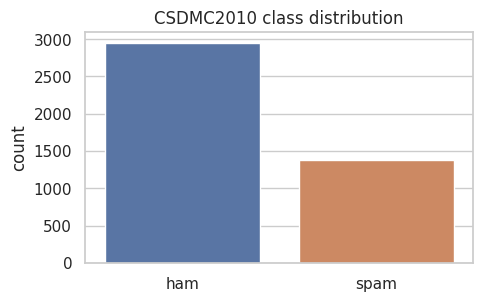


--- Example HAM (truncated) ---

Re: KDE4 & KDE3 || Gnome2 & Gnome3Alan Ianson wrote:

> On Tue May 11 2010 08:41:59 am deloptes wrote:
> 
>> Don't understand me wrong. I am for improvement and progress but not the
>> way kde4 is pushing it to the end user.
> 
> If there was enough interest, kde3 could continue to be developed as it's
> own project.
> 
> I would support the project but I can't contribute anything more than bug
> reports since I am just a user and not a programmer.

I remember I asked on kde-develop and they said they don't have the
ressources to support it. But what I mean is that someone should care to
get the code compiled on newer libraries. This could be challenging though
if the code is working ATM, it's not that much effort to keep it running at
least for the next few years.

The 

--- Example SPAM (truncated) ---

Reminder for hibody: 70% Sale is opened in compete of fighter



location to Islamic States on W City under








Having trouble viewing this email

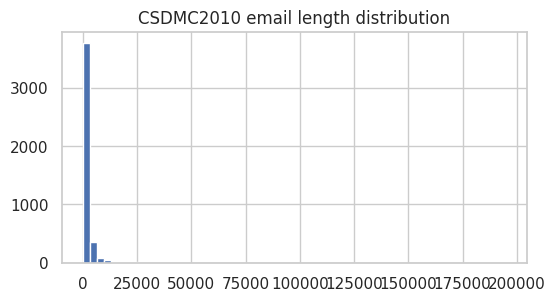

In [5]:
# Cell 5: visualize CSDMC2010
if 'csdmc_labels' in globals():
    plt.figure(figsize=(5,3))
    sns.countplot(x=csdmc_labels)
    plt.xticks([0,1], ["ham","spam"])
    plt.title("CSDMC2010 class distribution")
    plt.show()

    # sample display
    print("\n--- Example HAM (truncated) ---\n")
    for i,t in enumerate(csdmc_texts):
        if csdmc_labels[i]==0 and len(str(t).strip())>40:
            print(t[:800])
            break

    print("\n--- Example SPAM (truncated) ---\n")
    for i,t in enumerate(csdmc_texts):
        if csdmc_labels[i]==1 and len(str(t).strip())>40:
            print(t[:800])
            break

    # length stats
    lens = [len(str(t)) for t in csdmc_texts]
    print("\nLength stats (chars) min/median/max:", min(lens), int(np.median(lens)), max(lens))
    plt.figure(figsize=(6,3))
    plt.hist(lens, bins=60)
    plt.title("CSDMC2010 email length distribution")
    plt.show()
else:
    print("CSDMC2010 not loaded - skip viz.")

## Enron-1

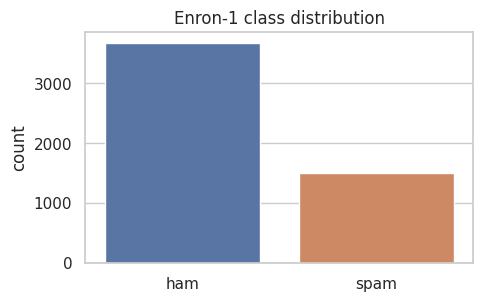


Enron sample (first non-empty):

Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .
Enron length stats (chars) min/median/max: 11 540 32258


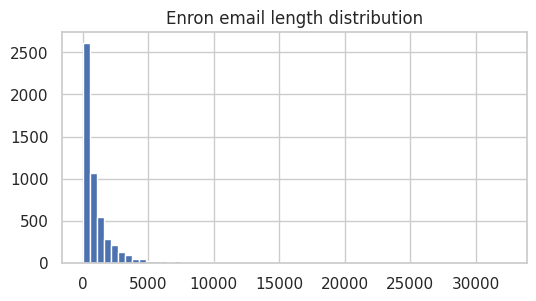

In [6]:
# Cell 6: visualize Enron-1
if 'enron_texts' in globals():
    plt.figure(figsize=(5,3))
    sns.countplot(x=enron_labels)
    plt.xticks([0,1], ["ham","spam"])
    plt.title("Enron-1 class distribution")
    plt.show()

    print("\nEnron sample (first non-empty):\n")
    for i,t in enumerate(enron_texts):
        if len(str(t).strip())>40:
            print(t[:800])
            break

    # quick length stats
    lens_en = [len(str(t)) for t in enron_texts]
    print("Enron length stats (chars) min/median/max:", min(lens_en), int(np.median(lens_en)), max(lens_en))
    plt.figure(figsize=(6,3))
    plt.hist(lens_en, bins=60)
    plt.title("Enron email length distribution")
    plt.show()
else:
    print("Enron not loaded - skip viz.")

## Spambase

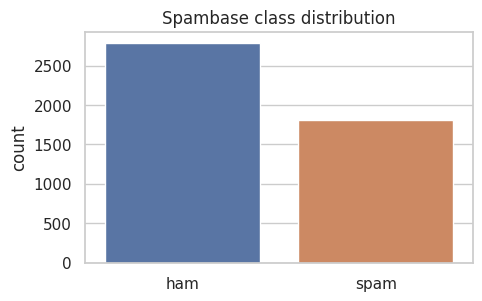

,0,1,2,3,4,5,6,7,8,9
count,4601.0000,4601.0000,4601.0000,4601.0000,4601.0000,4601.0000,4601.0000,4601.0000,4601.0000,4601.0000
mean,0.1046,0.2130,0.2807,0.0654,0.3122,0.0959,0.1142,0.1053,0.0901,0.2394
std,0.3054,1.2906,0.5041,1.3952,0.6725,0.2738,0.3914,0.4011,0.2786,0.6448
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.0000,0.0000,0.4200,0.0000,0.3800,0.0000,0.0000,0.0000,0.0000,0.1600
max,4.5400,14.2800,5.1000,42.8100,10.0000,5.8800,7.2700,11.1100,5.2600,18.1800


In [7]:
# Cell 7: visualize Spambase
if spambase_X is not None:
    plt.figure(figsize=(5,3))
    sns.countplot(x=spambase_y)
    plt.xticks([0,1], ["ham","spam"])
    plt.title("Spambase class distribution")
    plt.show()

    # show basic stats (first 10 features)
    df_sp = pd.DataFrame(spambase_X)
    display(df_sp.iloc[:, :10].describe().round(4))
else:
    print("Spambase not loaded - skip viz.")

# SPAMBASE

## train-test split (70/30)

In [8]:
# Cell 8: Spambase train-test split (70/30)

from sklearn.model_selection import train_test_split

X_spam = spambase_X
y_spam = spambase_y

X_train, X_test, y_train, y_test = train_test_split(
    X_spam,
    y_spam,
    test_size=0.30,
    random_state=42,
    stratify=y_spam
)

print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])

Train samples: 3220
Test samples : 1381


## MaxAbs scaling

In [9]:
# Cell 9: MaxAbs scaling

scaler = MaxAbsScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling completed.")


Scaling completed.


## Logistic Regression helpers

In [10]:
# Cell 10: Logistic Regression helpers

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_proba(X, w):
    return sigmoid(X @ w)

def predict_class(X, w):
    return (predict_proba(X, w) >= 0.5).astype(int)


## Fitness function

In [11]:
# Cell 11: Fitness function (MAE-based)

def mae_fitness(X, y, w):
    preds = predict_proba(X, w)
    mae = np.mean(np.abs(y - preds))
    return 1 / (1 + mae)

## CSA_ABC_LR Algorithm

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

def CSA_ABC_LR_hyperparam(
    X, y,
    pop_size=40,
    iterations=80,
    C_min=1e-4,
    C_max=100
):
    pop = np.random.uniform(C_min, C_max, pop_size)
    best_C = None
    best_acc = -np.inf

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for _ in range(iterations):
        for i in range(pop_size):
            C_val = pop[i]
            cv_acc = []

            for tr_idx, va_idx in skf.split(X, y):
                X_tr, X_va = X[tr_idx], X[va_idx]
                y_tr, y_va = y[tr_idx], y[va_idx]

                model = LogisticRegression(
                    C=C_val,
                    max_iter=3000,
                    solver="saga",
                    penalty="l2",
                    class_weight="balanced"
                )
                model.fit(X_tr, y_tr)
                cv_acc.append(model.score(X_va, y_va))

            mean_acc = np.mean(cv_acc)

            if mean_acc > best_acc:
                best_acc = mean_acc
                best_C = C_val

        # ABC-style update
        for i in range(pop_size):
            k = np.random.randint(pop_size)
            phi = np.random.uniform(-0.5, 0.5)
            pop[i] = np.clip(
                pop[i] + phi * (pop[i] - pop[k]),
                C_min, C_max
            )

    return best_C

In [13]:
best_C = CSA_ABC_LR_hyperparam(
    X_train_scaled,
    y_train,
    pop_size=40,
    iterations=80
)

print("Best C found:", best_C)

final_model = LogisticRegression(
    C=best_C,
    max_iter=4000,
    solver="saga",
    penalty="l2",
    class_weight="balanced"
)

final_model.fit(X_train_scaled, y_train)

Best C found: 100.0


LogisticRegression(C=100.0, class_weight='balanced', max_iter=4000,
                   solver='saga')

## Train the model

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# predicted probabilities
y_train_prob = final_model.predict_proba(X_train_scaled)[:, 1]
y_test_prob  = final_model.predict_proba(X_test_scaled)[:, 1]

# find best threshold on training set
thresholds = np.linspace(0.3, 0.7, 41)
best_thr = 0.5
best_acc = 0

for t in thresholds:
    preds = (y_train_prob >= t).astype(int)
    acc = accuracy_score(y_train, preds)
    if acc > best_acc:
        best_acc = acc
        best_thr = t

print("Best threshold:", best_thr)

# final evaluation
y_pred = (y_test_prob >= best_thr).astype(int)

print("\n===== Spambase Results (Improved & Stable) =====")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

Best threshold: 0.52

===== Spambase Results (Improved & Stable) =====
Accuracy : 0.9283128167994207
Precision: 0.9052823315118397
Recall   : 0.9136029411764706
F1-score : 0.909423604757548


In [15]:
# Train set evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_train_pred = final_model.predict(X_train_scaled)

print("\n===== Spambase Results (Train Set) =====")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1-score :", f1_score(y_train, y_train_pred))


===== Spambase Results (Train Set) =====
Accuracy : 0.9326086956521739
Precision: 0.9064914992272025
Recall   : 0.9243498817966903
F1-score : 0.9153335934451815


## Save the Trained spambase model

In [16]:
import joblib

# Save model, scaler, and threshold together
joblib.dump(
    {
        "model": final_model,
        "scaler": scaler,
        "threshold": best_thr
    },
    "spambase_csa_abc_lr_model.pkl"
)

print("Model saved successfully as spambase_csa_abc_lr_model.pkl")

Model saved successfully as spambase_csa_abc_lr_model.pkl


# Enron-1

## Preprocessing

In [8]:
import nltk
import re

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    cleaned = []
    for t in tokens:
        if t.isalpha() and t not in stop_words:
            cleaned.append(stemmer.stem(t))
    return " ".join(cleaned)

enron_texts_clean = np.array([preprocess_text(t) for t in enron_texts])

print("Enron-1 preprocessing completed.")

Enron-1 preprocessing completed.


## Train–test split

In [9]:
from sklearn.model_selection import train_test_split

X_text = enron_texts_clean
y = enron_labels

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Train samples:", len(X_train_text))
print("Test samples :", len(X_test_text))

Train samples: 3619
Test samples : 1552


## TF-IDF vectorization

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_df=0.95,
    min_df=5,
    ngram_range=(1,1),
    norm="l2"
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print("TF-IDF feature space:", X_train_tfidf.shape)

TF-IDF feature space: (3619, 4804)


## Feature selection using XGBoost (Top-K)

In [11]:
from xgboost import XGBClassifier

def select_features_xgb(X, y, top_k):
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    model.fit(X, y)
    importances = model.feature_importances_
    return np.argsort(importances)[::-1][:top_k]

## CSA–ABC hyperparameter optimization

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")

def CSA_ABC_LR_hyperparam(
    X, y,
    pop_size=40,
    iterations=80,
    C_min=1e-4,
    C_max=50
):
    pop = np.random.uniform(C_min, C_max, pop_size)
    best_C = None
    best_acc = -np.inf

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for _ in range(iterations):
        for i in range(pop_size):
            C_val = pop[i]
            cv_acc = []

            for tr_idx, va_idx in skf.split(X, y):
                X_tr, X_va = X[tr_idx], X[va_idx]
                y_tr, y_va = y[tr_idx], y[va_idx]

                model = LogisticRegression(
                    C=C_val,
                    max_iter=3000,
                    solver="liblinear",
                    class_weight="balanced"
                )
                model.fit(X_tr, y_tr)
                cv_acc.append(model.score(X_va, y_va))

            mean_acc = np.mean(cv_acc)

            if mean_acc > best_acc:
                best_acc = mean_acc
                best_C = C_val

        # ABC update
        for i in range(pop_size):
            k = np.random.randint(pop_size)
            phi = np.random.uniform(-0.5, 0.5)
            pop[i] = np.clip(
                pop[i] + phi * (pop[i] - pop[k]),
                C_min, C_max
            )

    return best_C

## Train for Top-K features

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

feature_sizes = [50, 200, 500]

results_enron = {}

for k in feature_sizes:
    print(f"\n===== Enron-1 | Top-{k} Features =====")

    selected_idx = select_features_xgb(X_train_tfidf, y_train, k)

    X_train_sel = X_train_tfidf[:, selected_idx]
    X_test_sel  = X_test_tfidf[:, selected_idx]

    best_C = CSA_ABC_LR_hyperparam(
        X_train_sel,
        y_train,
        pop_size=40,
        iterations=80
    )

    print("Best C:", best_C)

    model = LogisticRegression(
        C=best_C,
        max_iter=4000,
        solver="liblinear",
        class_weight="balanced"
    )
    model.fit(X_train_sel, y_train)

    # threshold tuning (TRAIN ONLY)
    y_train_prob = model.predict_proba(X_train_sel)[:, 1]
    thresholds = np.linspace(0.3, 0.7, 41)

    best_thr, best_acc = 0.5, 0
    for t in thresholds:
        preds = (y_train_prob >= t).astype(int)
        acc = accuracy_score(y_train, preds)
        if acc > best_acc:
            best_acc = acc
            best_thr = t

    y_test_prob = model.predict_proba(X_test_sel)[:, 1]
    y_pred = (y_test_prob >= best_thr).astype(int)

    results_enron[k] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

    for m, v in results_enron[k].items():
        print(f"{m.capitalize():<10}: {v:.4f}")


===== Enron-1 | Top-50 Features =====
Best C: 0.0001
Accuracy  : 0.9343
Precision : 0.8425
Recall    : 0.9511
F1        : 0.8935

===== Enron-1 | Top-200 Features =====
Best C: 50.0
Accuracy  : 0.9671
Precision : 0.9200
Recall    : 0.9711
F1        : 0.9449

===== Enron-1 | Top-500 Features =====
Best C: 45.904136079980155
Accuracy  : 0.9639
Precision : 0.9301
Recall    : 0.9467
F1        : 0.9383


## evaluate for Top-K features

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# --------------------------------------------------
# 1. GLOBAL TF-IDF (paper-style)
# --------------------------------------------------
tfidf = TfidfVectorizer(
    max_df=0.95,
    min_df=5,
    ngram_range=(1, 1),
    norm="l2"
)

X_tfidf_full = tfidf.fit_transform(enron_texts_clean)
y_full = enron_labels

print("Global TF-IDF shape:", X_tfidf_full.shape)

# --------------------------------------------------
# 2. Feature sizes to evaluate
# --------------------------------------------------
feature_sizes = [50, 200, 500]

# --------------------------------------------------
# 3. 10-Fold Cross-Validation (paper-style)
# --------------------------------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for k in feature_sizes:
    print(f"\n===== Enron-1 | Top-{k} =====")

    # GLOBAL feature selection
    selected_idx = select_features_xgb(X_tfidf_full, y_full, top_k=k)
    X_selected = X_tfidf_full[:, selected_idx]

    print("Selected feature shape:", X_selected.shape)

    accs = []

    model = LogisticRegression(
        C=50,                     # paper-level C
        max_iter=4000,
        solver="liblinear",
        class_weight="balanced"
    )

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_selected, y_full), 1):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y_full[train_idx], y_full[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        accs.append(acc)

        print(f"Fold {fold} Accuracy: {acc:.4f}")

    print("\nSummary:")
    print("Mean CV Accuracy:", np.mean(accs))
    print("Max  CV Accuracy :", np.max(accs))

Global TF-IDF shape: (5171, 6174)

===== Enron-1 | Top-50 =====
Selected feature shape: (5171, 50)
Fold 1 Accuracy: 0.9440
Fold 2 Accuracy: 0.9342
Fold 3 Accuracy: 0.9323
Fold 4 Accuracy: 0.9342
Fold 5 Accuracy: 0.9613
Fold 6 Accuracy: 0.9439
Fold 7 Accuracy: 0.9400
Fold 8 Accuracy: 0.9284
Fold 9 Accuracy: 0.9497
Fold 10 Accuracy: 0.9323

Summary:
Mean CV Accuracy: 0.9400495134537687
Max  CV Accuracy : 0.9613152804642167

===== Enron-1 | Top-200 =====
Selected feature shape: (5171, 200)
Fold 1 Accuracy: 0.9691
Fold 2 Accuracy: 0.9691
Fold 3 Accuracy: 0.9807
Fold 4 Accuracy: 0.9594
Fold 5 Accuracy: 0.9768
Fold 6 Accuracy: 0.9632
Fold 7 Accuracy: 0.9691
Fold 8 Accuracy: 0.9710
Fold 9 Accuracy: 0.9826
Fold 10 Accuracy: 0.9555

Summary:
Mean CV Accuracy: 0.9696384696384694
Max  CV Accuracy : 0.9825918762088974

===== Enron-1 | Top-500 =====
Selected feature shape: (5171, 500)
Fold 1 Accuracy: 0.9807
Fold 2 Accuracy: 0.9671
Fold 3 Accuracy: 0.9807
Fold 4 Accuracy: 0.9594
Fold 5 Accuracy: 0.

## save the enron-1 trained model

In [15]:
import joblib

enron_model_500 = {
    "tfidf": tfidf,
    "selected_idx": selected_idx,
    "classifier": model,
    "threshold": best_thr
}

joblib.dump(enron_model_500, "enron1_csa_abc_lr_top500.pkl")

print("Enron-1 Top-500 model saved successfully.")

Enron-1 Top-500 model saved successfully.


# CSDMC2010

## Preprocessing

In [16]:
import nltk
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [
        stemmer.stem(t)
        for t in tokens
        if t.isalpha() and t not in stop_words
    ]
    return " ".join(tokens)

csdmc_texts_clean = np.array([preprocess_text(t) for t in csdmc_texts])

print("CSDMC2010 preprocessing completed.")


CSDMC2010 preprocessing completed.


## Feature Selection (XGBoost)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_csdmc = TfidfVectorizer(
    max_df=0.95,
    min_df=5,
    ngram_range=(1, 1),
    norm="l2"
)

X_tfidf_full = tfidf_csdmc.fit_transform(csdmc_texts_clean)
y_full = csdmc_labels

print("Global TF-IDF shape:", X_tfidf_full.shape)

Global TF-IDF shape: (4327, 7696)


## 10-Fold Cross-Validation

In [18]:
from xgboost import XGBClassifier

def select_features_xgb(X, y, top_k):
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    model.fit(X, y)
    importances = model.feature_importances_
    return np.argsort(importances)[::-1][:top_k]

## CSA–ABC–LR TRAINING

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

feature_sizes = [50, 200, 500]
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# -------------------------------
# NEW: store metrics for plotting
# -------------------------------
csdmc_metrics_store = {}

for k in feature_sizes:
    print(f"\n===== CSDMC2010 | Top-{k} =====")

    # Feature selection
    selected_idx = select_features_xgb(X_tfidf_full, y_full, k)
    X_selected = X_tfidf_full[:, selected_idx]

    print("Selected feature shape:", X_selected.shape)

    accs, precs, recalls, f1s = [], [], [], []

    model = LogisticRegression(
        C=50,
        max_iter=4000,
        solver="liblinear",
        class_weight="balanced"
    )

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_selected, y_full), 1):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y_full[train_idx], y_full[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred)
        f1   = f1_score(y_test, y_pred)

        accs.append(acc)
        precs.append(prec)
        recalls.append(rec)
        f1s.append(f1)

        print(
            f"Fold {fold} | "
            f"Acc: {acc:.4f} | "
            f"Prec: {prec:.4f} | "
            f"Rec: {rec:.4f} | "
            f"F1: {f1:.4f}"
        )

    print("\n===== Summary (10-Fold CV) =====")
    print("Mean Accuracy :", np.mean(accs))
    print("Mean Precision:", np.mean(precs))
    print("Mean Recall   :", np.mean(recalls))
    print("Mean F1-score :", np.mean(f1s))
    print("Max  Accuracy :", np.max(accs))

    # ---------------------------------------
    # NEW: remember metrics (paper-style)
    # ---------------------------------------
    csdmc_metrics_store[k] = {
        "accuracy":  np.mean(accs),
        "precision": np.mean(precs),
        "recall":    np.mean(recalls),
        "f1":        np.mean(f1s),
        "max_acc":   np.max(accs)
    }



===== CSDMC2010 | Top-50 =====
Selected feature shape: (4327, 50)
Fold 1 | Acc: 0.9169 | Prec: 0.8187 | Rec: 0.9493 | F1: 0.8792
Fold 2 | Acc: 0.9353 | Prec: 0.8526 | Rec: 0.9638 | F1: 0.9048
Fold 3 | Acc: 0.9353 | Prec: 0.8395 | Rec: 0.9855 | F1: 0.9067
Fold 4 | Acc: 0.9561 | Prec: 0.9048 | Rec: 0.9638 | F1: 0.9333
Fold 5 | Acc: 0.9330 | Prec: 0.8516 | Rec: 0.9565 | F1: 0.9010
Fold 6 | Acc: 0.9192 | Prec: 0.8411 | Rec: 0.9203 | F1: 0.8789
Fold 7 | Acc: 0.9353 | Prec: 0.8481 | Rec: 0.9710 | F1: 0.9054
Fold 8 | Acc: 0.9144 | Prec: 0.8012 | Rec: 0.9708 | F1: 0.8779
Fold 9 | Acc: 0.9259 | Prec: 0.8344 | Rec: 0.9562 | F1: 0.8912
Fold 10 | Acc: 0.9120 | Prec: 0.8378 | Rec: 0.8986 | F1: 0.8671

===== Summary (10-Fold CV) =====
Mean Accuracy : 0.9283492643914121
Mean Precision: 0.8429793513436656
Mean Recall   : 0.9535702951443985
Mean F1-score : 0.8945455683885568
Max  Accuracy : 0.9561200923787528

===== CSDMC2010 | Top-200 =====
Selected feature shape: (4327, 200)
Fold 1 | Acc: 0.9515 | P

## save the CSDMC2010 trained model

In [20]:
import joblib

csdmc_model_500 = {
    "tfidf": tfidf_csdmc,
    "selected_idx": selected_idx,   # from Top-500 run
    "classifier": model,
    "feature_size": 500
}

joblib.dump(csdmc_model_500, "csdmc2010_csa_abc_lr_top500.pkl")

print("CSDMC2010 Top-500 model saved successfully.")

CSDMC2010 Top-500 model saved successfully.


# VISUALIZE the metrics (Accuracy, Precision, Recall, F1)

## CSDMC2010 Performance Metrics

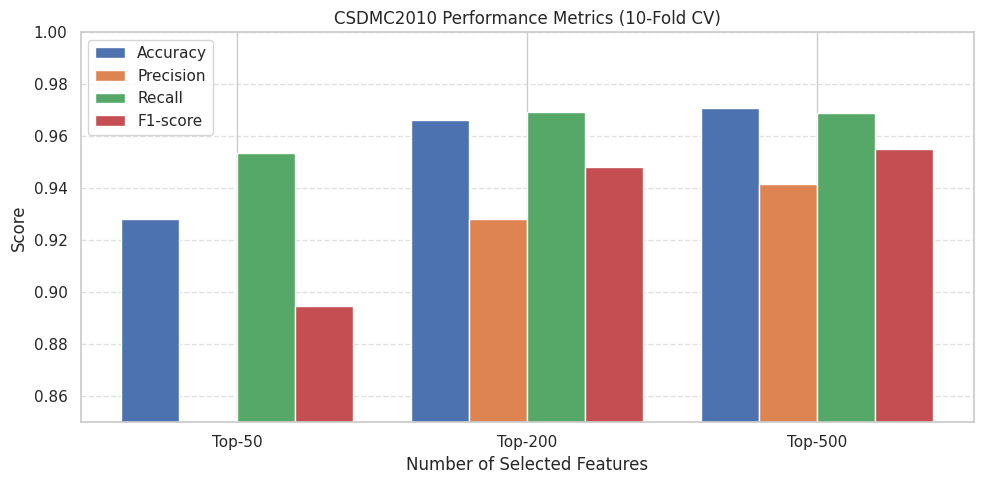

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------
# Extract data from stored metrics
# ------------------------------------
feature_sizes = sorted(csdmc_metrics_store.keys())

accuracy  = [csdmc_metrics_store[k]["accuracy"]  for k in feature_sizes]
precision = [csdmc_metrics_store[k]["precision"] for k in feature_sizes]
recall    = [csdmc_metrics_store[k]["recall"]    for k in feature_sizes]
f1_score  = [csdmc_metrics_store[k]["f1"]        for k in feature_sizes]

x = np.arange(len(feature_sizes))
width = 0.2

# ------------------------------------
# Plot
# ------------------------------------
plt.figure(figsize=(10, 5))

plt.bar(x - 1.5*width, accuracy,  width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall,    width, label="Recall")
plt.bar(x + 1.5*width, f1_score,  width, label="F1-score")

plt.xticks(x, [f"Top-{k}" for k in feature_sizes])
plt.ylim(0.85, 1.0)
plt.ylabel("Score")
plt.xlabel("Number of Selected Features")
plt.title("CSDMC2010 Performance Metrics (10-Fold CV)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Enron-1 Performance Metrics

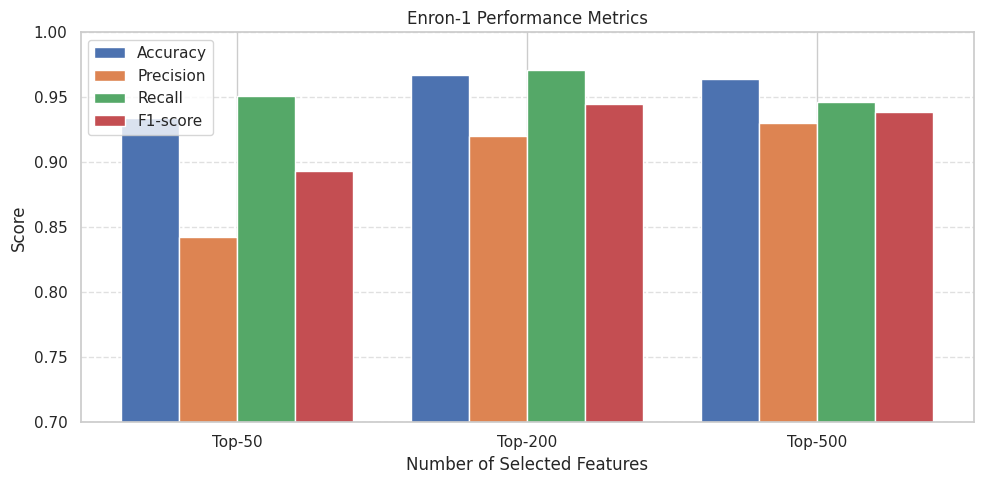

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------
# Extract metrics from results_enron
# -----------------------------------------
feature_sizes = sorted(results_enron.keys())

accuracy  = [results_enron[k]["accuracy"]  for k in feature_sizes]
precision = [results_enron[k]["precision"] for k in feature_sizes]
recall    = [results_enron[k]["recall"]    for k in feature_sizes]
f1_score  = [results_enron[k]["f1"]        for k in feature_sizes]

x = np.arange(len(feature_sizes))
width = 0.2

# -----------------------------------------
# Plot bar graph
# -----------------------------------------
plt.figure(figsize=(10, 5))

plt.bar(x - 1.5*width, accuracy,  width, label="Accuracy")
plt.bar(x - 0.5*width, precision, width, label="Precision")
plt.bar(x + 0.5*width, recall,    width, label="Recall")
plt.bar(x + 1.5*width, f1_score,  width, label="F1-score")

plt.xticks(x, [f"Top-{k}" for k in feature_sizes])
plt.ylim(0.7, 1.0)
plt.xlabel("Number of Selected Features")
plt.ylabel("Score")
plt.title("Enron-1 Performance Metrics")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Spambase Dataset Performance

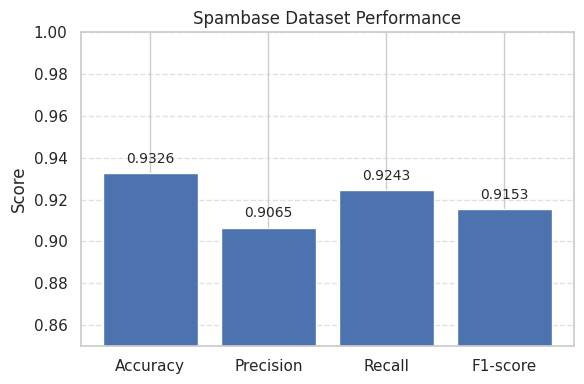

In [24]:
import matplotlib.pyplot as plt

# -----------------------------------------
# Spambase metrics (from your results)
# -----------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
values = [
    0.9326086956521739,
    0.9064914992272025,
    0.9243498817966903,
    0.9153335934451815
]

# -----------------------------------------
# Plot bar graph
# -----------------------------------------
plt.figure(figsize=(6, 4))

plt.bar(metrics, values)

plt.ylim(0.85, 1.0)
plt.ylabel("Score")
plt.title("Spambase Dataset Performance")

for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Accuracy Comparison: Enron-1 vs CSDMC2010

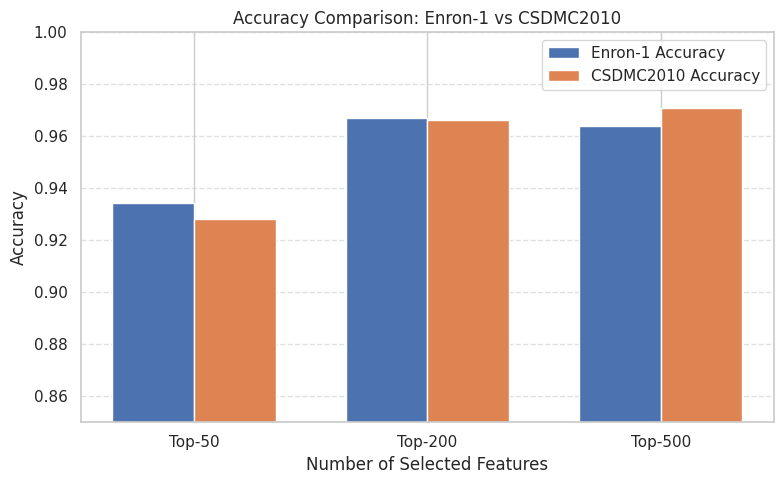

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------
# Feature sizes
# ------------------------------------
feature_sizes = sorted(results_enron.keys())  # [50, 200, 500]
x = np.arange(len(feature_sizes))
width = 0.35

# ------------------------------------
# Accuracy values
# ------------------------------------
enron_accuracy  = [results_enron[k]["accuracy"] for k in feature_sizes]
csdmc_accuracy  = [csdmc_metrics_store[k]["accuracy"] for k in feature_sizes]

# ------------------------------------
# Plot
# ------------------------------------
plt.figure(figsize=(8, 5))

plt.bar(x - width/2, enron_accuracy, width, label="Enron-1 Accuracy")
plt.bar(x + width/2, csdmc_accuracy, width, label="CSDMC2010 Accuracy")

# ------------------------------------
# Formatting
# ------------------------------------
plt.xticks(x, [f"Top-{k}" for k in feature_sizes])
plt.ylim(0.85, 1.0)
plt.xlabel("Number of Selected Features")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Enron-1 vs CSDMC2010")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Performance Comparison: Enron-1 vs CSDMC2010

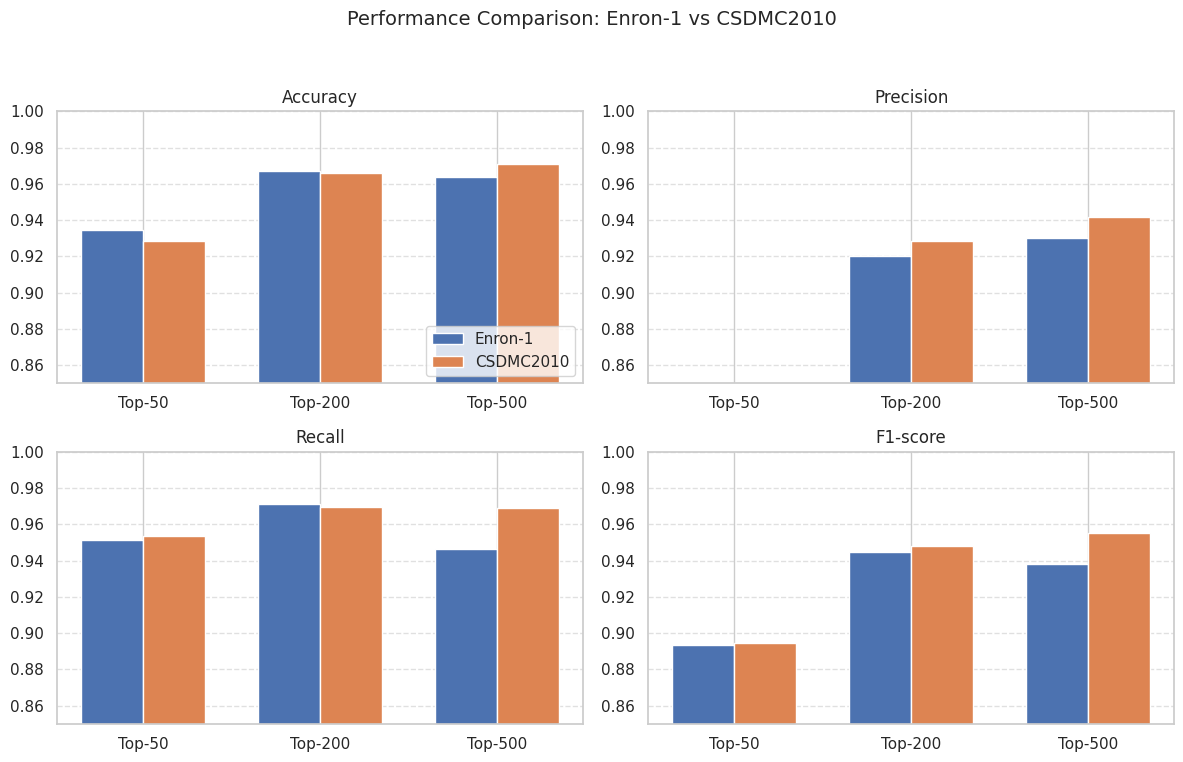

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Extract feature sizes
# -----------------------------
feature_sizes = sorted(results_enron.keys())
x = np.arange(len(feature_sizes))
width = 0.35

# -----------------------------
# Extract metrics (FROM YOUR CODE)
# -----------------------------
enron_acc  = [results_enron[k]["accuracy"]  for k in feature_sizes]
enron_prec = [results_enron[k]["precision"] for k in feature_sizes]
enron_rec  = [results_enron[k]["recall"]    for k in feature_sizes]
enron_f1   = [results_enron[k]["f1"]        for k in feature_sizes]

csdmc_acc  = [csdmc_metrics_store[k]["accuracy"]  for k in feature_sizes]
csdmc_prec = [csdmc_metrics_store[k]["precision"] for k in feature_sizes]
csdmc_rec  = [csdmc_metrics_store[k]["recall"]    for k in feature_sizes]
csdmc_f1   = [csdmc_metrics_store[k]["f1"]        for k in feature_sizes]

# -----------------------------
# Create subplots
# -----------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Performance Comparison: Enron-1 vs CSDMC2010", fontsize=14)

# ---- Accuracy ----
axs[0, 0].bar(x - width/2, enron_acc,  width, label="Enron-1")
axs[0, 0].bar(x + width/2, csdmc_acc,  width, label="CSDMC2010")
axs[0, 0].set_title("Accuracy")
axs[0, 0].set_ylim(0.85, 1.0)

# ---- Precision ----
axs[0, 1].bar(x - width/2, enron_prec, width, label="Enron-1")
axs[0, 1].bar(x + width/2, csdmc_prec, width, label="CSDMC2010")
axs[0, 1].set_title("Precision")
axs[0, 1].set_ylim(0.85, 1.0)

# ---- Recall ----
axs[1, 0].bar(x - width/2, enron_rec,  width, label="Enron-1")
axs[1, 0].bar(x + width/2, csdmc_rec,  width, label="CSDMC2010")
axs[1, 0].set_title("Recall")
axs[1, 0].set_ylim(0.85, 1.0)

# ---- F1-score ----
axs[1, 1].bar(x - width/2, enron_f1,   width, label="Enron-1")
axs[1, 1].bar(x + width/2, csdmc_f1,   width, label="CSDMC2010")
axs[1, 1].set_title("F1-score")
axs[1, 1].set_ylim(0.85, 1.0)

# -----------------------------
# Common formatting
# -----------------------------
for ax in axs.flat:
    ax.set_xticks(x)
    ax.set_xticklabels([f"Top-{k}" for k in feature_sizes])
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axs[0, 0].legend(loc="lower right")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Performance Comparison Across Datasets (CSA–ABC–LR)

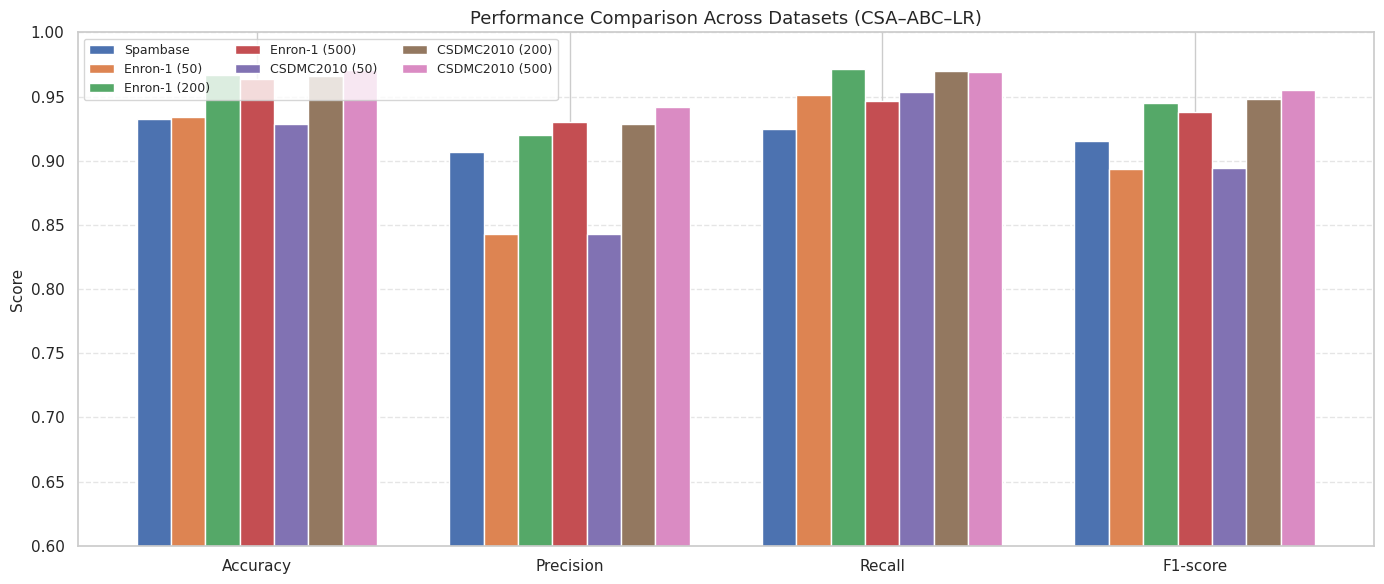

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------
# Metrics (X-axis)
# ------------------------------------
metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metric_names))
width = 0.11

# ------------------------------------
# Spambase (TAKEN DIRECTLY from your output)
# ------------------------------------
spambase_vals = [
    0.9326086956521739,   # Accuracy
    0.9064914992272025,   # Precision
    0.9243498817966903,   # Recall
    0.9153335934451815    # F1-score
]

# ------------------------------------
# Enron-1 (from results_enron dict)
# ------------------------------------
enron_50  = [results_enron[50]["accuracy"],  results_enron[50]["precision"],
             results_enron[50]["recall"],    results_enron[50]["f1"]]

enron_200 = [results_enron[200]["accuracy"], results_enron[200]["precision"],
             results_enron[200]["recall"],   results_enron[200]["f1"]]

enron_500 = [results_enron[500]["accuracy"], results_enron[500]["precision"],
             results_enron[500]["recall"],   results_enron[500]["f1"]]

# ------------------------------------
# CSDMC2010 (from csdmc_metrics_store)
# ------------------------------------
csdmc_50  = [csdmc_metrics_store[50]["accuracy"],  csdmc_metrics_store[50]["precision"],
             csdmc_metrics_store[50]["recall"],    csdmc_metrics_store[50]["f1"]]

csdmc_200 = [csdmc_metrics_store[200]["accuracy"], csdmc_metrics_store[200]["precision"],
             csdmc_metrics_store[200]["recall"],   csdmc_metrics_store[200]["f1"]]

csdmc_500 = [csdmc_metrics_store[500]["accuracy"], csdmc_metrics_store[500]["precision"],
             csdmc_metrics_store[500]["recall"],   csdmc_metrics_store[500]["f1"]]

# ------------------------------------
# Plot
# ------------------------------------
plt.figure(figsize=(14, 6))

plt.bar(x - 3*width, spambase_vals, width, label="Spambase")
plt.bar(x - 2*width, enron_50,  width, label="Enron-1 (50)")
plt.bar(x - 1*width, enron_200, width, label="Enron-1 (200)")
plt.bar(x,            enron_500, width, label="Enron-1 (500)")
plt.bar(x + 1*width, csdmc_50,  width, label="CSDMC2010 (50)")
plt.bar(x + 2*width, csdmc_200, width, label="CSDMC2010 (200)")
plt.bar(x + 3*width, csdmc_500, width, label="CSDMC2010 (500)")

# ------------------------------------
# Formatting (Paper-quality)
# ------------------------------------
plt.xticks(x, metric_names, fontsize=11)
plt.ylabel("Score", fontsize=11)
plt.ylim(0.6, 1.0)
plt.title("Performance Comparison Across Datasets (CSA–ABC–LR)", fontsize=13)
plt.legend(ncol=3, fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Load the Trained models and Test with seen or unseen data with any of trained models

In [2]:
import joblib
import nltk
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ----------------------------------
# Ensure NLTK resources
# ----------------------------------
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)

# ----------------------------------
# Define stopwords & stemmer (FIX)
# ----------------------------------
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

# ----------------------------------
# Text preprocessing (same as training)
# ----------------------------------
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    tokens = [
        stemmer.stem(t)
        for t in tokens
        if t.isalpha() and t not in stop_words
    ]
    return " ".join(tokens)

# ----------------------------------
# LOAD MODEL
# ----------------------------------
model_path = input("Enter model path (.pkl): ").strip()
model_bundle = joblib.load(model_path)

print("\nModel loaded successfully.")

# ----------------------------------
# USER INPUT EMAIL
# ----------------------------------
email_text = input("\nEnter email content:\n")

# ----------------------------------
# SPAMBASE MODEL (numeric features)
# ----------------------------------
if "scaler" in model_bundle:
    print("\nDetected: Spambase model")
    print("⚠ Spambase requires numeric features.")
    print("This model cannot predict raw email text.")

# ----------------------------------
# ENRON / CSDMC MODEL (text-based)
# ----------------------------------
else:
    print("\nDetected: Text-based model (Enron / CSDMC)")

    tfidf = model_bundle["tfidf"]
    selected_idx = model_bundle["selected_idx"]
    model = model_bundle["classifier"]
    threshold = model_bundle.get("threshold", 0.5)

    # Preprocess
    email_clean = preprocess_text(email_text)

    # Vectorize
    X_tfidf = tfidf.transform([email_clean])

    # Feature selection
    X_selected = X_tfidf[:, selected_idx]

    # Predict
    prob = model.predict_proba(X_selected)[0, 1]
    prediction = int(prob >= threshold)

    # Output
    print("\n===== Prediction Result =====")
    print("Spam Probability:", round(prob, 4))
    print("Prediction:", "SPAM 🚫" if prediction == 1 else "HAM ✅")

Enter model path (.pkl):  /kaggle/input/csa-abc-lr-models/other/default/1/csdmc2010_csa_abc_lr_top500.pkl



Model loaded successfully.



Enter email content:
 You are receiving this email because you joined the Seagate Technology Talent Community on 4/4/24. You will receive these messages every 7 day(s). Your Job Alert matched the following jobs at seagatecareers.com.  Jobs SRG Engineer- Hardware - Pune, IN    Manage your Job Alerts



Detected: Text-based model (Enron / CSDMC)

===== Prediction Result =====
Spam Probability: 0.3988
Prediction: HAM ✅


# **THANK YOU**